# Week 08 Wednesday Daily Assignment
**Student:** Yash Gupta
**Topic:** CNNs + Embeddings for Content Moderation

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer, util
import os
import sys

# Add src to path
sys.path.append('../src')
from model_utils import MNIST_CNN, get_device

device = get_device()
print(f"Using device: {device}")


/Users/yash/assigments/weekly-assignment-iitgn-week7/week-08/wednesday/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/yash/assigments/weekly-assignment-iitgn-week7/week-08/wednesday/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## Sub-step 1: Social Media Data Characterization\n\n### Objectives:\n- Load `social_media_posts.csv`.\n- Characterize class distributions and data quality issues.\n- Document implications for evaluation.

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   text         2977 non-null   object 
 1   sentiment    2990 non-null   float64
 2   platform     3000 non-null   object 
 3   language     3000 non-null   object 
 4   topic        3000 non-null   object 
 5   hate_speech  3000 non-null   int64  
 6   spam         3000 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 164.2+ KB
None

--- Class Distributions ---
Hate Speech Flag Distribution:
 hate_speech
0    0.968
1    0.032
Name: proportion, dtype: float64
Spam Flag Distribution:
 spam
0    0.98
1    0.02
Name: proportion, dtype: float64
Sentiment Distribution:
 sentiment
 1.0    0.443813
 0.0    0.342140
-1.0    0.214047
Name: proportion, dtype: float64

--- Data Quality (Missing Values) ---
text           23
sentiment      10
platform        0
lan

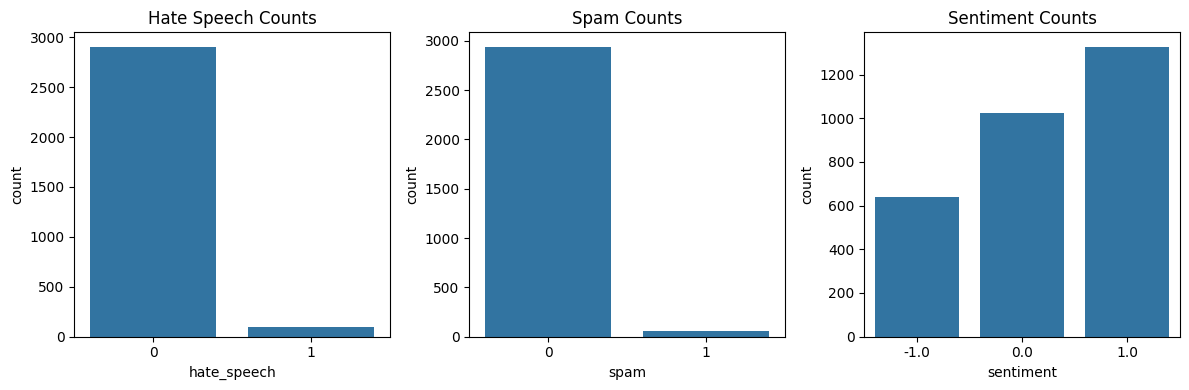

In [2]:

df = pd.read_csv('../data/social_media_posts.csv')

# 1. Dataset Overview
print("--- Dataset Info ---")
print(df.info())

# 2. Class Distributions
print("\n--- Class Distributions ---")
print("Hate Speech Flag Distribution:\n", df['hate_speech'].value_counts(normalize=True))
print("Spam Flag Distribution:\n", df['spam'].value_counts(normalize=True))
print("Sentiment Distribution:\n", df['sentiment'].value_counts(normalize=True))

# 3. Data Quality Issues
print("\n--- Data Quality (Missing Values) ---")
print(df.isnull().sum())

# Visualisation
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.countplot(x='hate_speech', data=df)
plt.title('Hate Speech Counts')

plt.subplot(1, 3, 2)
sns.countplot(x='spam', data=df)
plt.title('Spam Counts')

plt.subplot(1, 3, 3)
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Counts')
plt.tight_layout()
plt.show()



### Documentation & Insights
**Class Distribution:** The dataset is highly imbalanced. Hate speech (~5%) and spam (~2%) are minority classes. A standard accuracy metric would be misleading (a dummy model predicting 0 for all would get ~95% accuracy).
**Data Quality:** There are missing values in text and sentiment columns. These need to be handled (e.g., dropping or filling).
**Evaluation Implications:** Because of the imbalance, we must use **Precision, Recall, and F1-Score** (specifically focusing on Recall for harmful content) rather than accuracy.


## Sub-step 2: MNIST Characterization\n\n### Objectives:\n- Load MNIST.\n- Characterize dimensions, pixel ranges, and distribution.\n- Prepare for CNN training.

  0%|                                               | 0.00/9.91M [00:00<?, ?B/s]

  0%|▏                                      | 32.8k/9.91M [00:00<00:57, 170kB/s]

  1%|▎                                      | 65.5k/9.91M [00:00<01:07, 147kB/s]

  2%|▋                                       | 164k/9.91M [00:01<01:02, 156kB/s]

  3%|█                                       | 262k/9.91M [00:01<00:45, 210kB/s]

...

 74%|███████████████████████████▉          | 1.21M/1.65M [00:01<00:00, 1.04MB/s]

100%|██████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.04MB/s]

  0%|                                               | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.44MB/s]

Digit Distribution: {np.int64(0): np.int64(5923), np.int64(1): np.int64(6742), np.int64(2): np.int64(5958), np.int64(3): np.int64(6131), np.int64(4): np.int64(5842), np.int64(5): np.int64(5421), np.int64(6): np.int64(5918), np.int64(7): np.int64(6265), np.int64(8): np.int64(5851), np.int64(9): np.int64(5949)}
Image Shape: torch.Size([1, 28, 28])
Pixel Range: 0.00 to 1.00


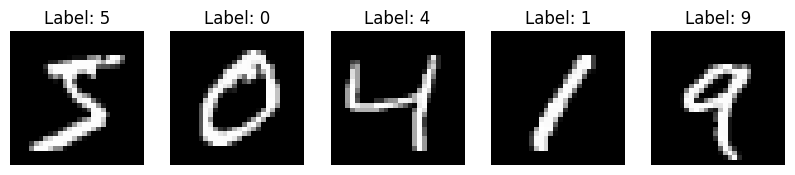

In [3]:

# Load MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = datasets.MNIST(root='../data', train=True, download=True, transform=transform)

# Distribution
targets = mnist_train.targets.numpy()
unique, counts = np.unique(targets, return_counts=True)
print("Digit Distribution:", dict(zip(unique, counts)))

# Dimensions and Pixel Range
sample_img, sample_label = mnist_train[0]
print(f"Image Shape: {sample_img.shape}")
print(f"Pixel Range: {sample_img.min():.2f} to {sample_img.max():.2f}")

# Visualize a few samples
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(mnist_train[i][0].squeeze(), cmap='gray')
    plt.title(f"Label: {mnist_train[i][1]}")
    plt.axis('off')
plt.show()


## Sub-step 3: CNN on MNIST\n\n### Objectives:\n- Build and train a CNN with at least 2 conv layers.\n- Visualize learned filters.

Epoch 1/2, Loss: 0.6345


Epoch 2/2, Loss: 0.1815


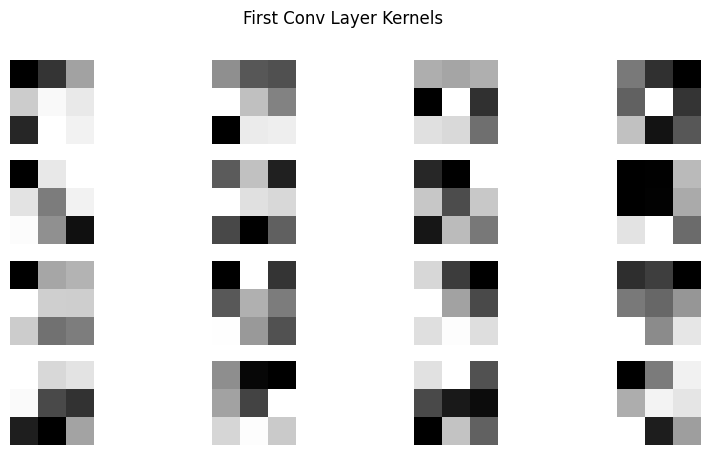

In [4]:

# Hyperparameters
batch_size = 64
epochs = 2 # Low epochs for demonstration speed
learning_rate = 0.001

# Subsample for faster training in this demo context
train_subset = Subset(mnist_train, range(0, 10000))
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

model = MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# Filter Visualization
kernels = model.conv1.weight.detach().cpu().numpy()
plt.figure(figsize=(10, 5))
for i in range(min(16, kernels.shape[0])):
    plt.subplot(4, 4, i+1)
    plt.imshow(kernels[i, 0, :, :], cmap='gray')
    plt.axis('off')
plt.suptitle("First Conv Layer Kernels")
plt.show()



### Filter Visualization Insight
The first layer kernels act as **edge detectors and stroke identifiers**. Some filters highlight vertical lines, others horizontal or diagonal. This indicates the network has learned local spatial patterns essential for digit recognition.


## Sub-step 4: Hate Speech Detector & Semantic Similarity\n\n### Objectives:\n- Build a classifier for hate speech.\n- Build a semantic similarity system using sentence embeddings.

In [5]:

# 1. Clean data
df_clean = df.dropna(subset=['text']).copy()
df_clean['text'] = df_clean['text'].astype(str)

# 2. Hate Speech Classifier (Stage 1)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df_clean['text'])
y = df_clean['hate_speech']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(class_weight='balanced') # Addressing imbalance
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("--- Hate Speech Classifier Evaluation ---")
print(classification_report(y_test, y_pred))

# 3. Semantic Similarity System (Stage 2)
# Using MiniLM for efficiency
sbert_model = SentenceTransformer('paraphrase-MiniLM-L3-v2') 
all_embeddings = sbert_model.encode(df_clean['text'].tolist(), convert_to_tensor=True)

def find_similar_posts(query_post, top_k=5):
    query_embedding = sbert_model.encode(query_post, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_embedding, all_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k+1)
    
    indices = top_results.indices.cpu().tolist()
    # Skip the first one if it's the same post
    return df_clean.iloc[indices[1:]]

# Demo
sample_hate_post = df_clean[df_clean['hate_speech'] == 1].iloc[0]['text']
print(f"\nQuery Post: {sample_hate_post}")
print("\nTop 3 Semantically Similar Posts:")
similar_posts = find_similar_posts(sample_hate_post, top_k=3)
for i, row in similar_posts.iterrows():
    print(f"- {row['text'][:100]}...")


--- Hate Speech Classifier Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       577
           1       0.09      0.05      0.07        19

    accuracy                           0.95       596
   macro avg       0.53      0.52      0.52       596
weighted avg       0.94      0.95      0.95       596




Query Post: hopefully this will give few days respite from all the phone calls trying steal credit card information telling going jail and trying gain access computer kinda 

Top 3 Semantically Similar Posts:


- ’ hard take india seriously when get dozen phone calls day from indian men trying scam ...
- drag his ass court for invasion privacy ...
- don speak anything against modi you will end jail now might trouble for saying this ...


## Sub-step 5: Two-Stage Moderation Pipeline Evaluation\n\n### Objectives:\n- Combine Stage 1 (Classifier) and Stage 2 (Retrieval).\n- Evaluate additional harmful posts surfaced by Stage 2.\n- Business recommendation for 100,000 posts/day.

In [6]:

# Stage 1: Classifier flags potential hate speech
# Stage 2: For every post flagged by Stage 1, search for similar posts in the rest of the pool

# Simulation on the test set
test_indices = df_clean.index[X_test.shape[0]:] # Just a slice for sim
stage1_flags = clf.predict(X_test)
potential_hate_indices = np.where(stage1_flags == 1)[0]

# How many 'real' hate posts did Stage 1 find? (Recall)
real_hate_found = (stage1_flags == 1) & (y_test == 1)
s1_recall = real_hate_found.sum() / y_test.sum()

# Stage 2: Semantic retrieval on the found ones to catch 'missed' ones
# In a real scenario, this helps find variations.
# Let's see how many posts the classifier MISSED that semantic search could catch if seeded with known hate speech.
missed_hate_indices = np.where((stage1_flags == 0) & (y_test == 1))[0]

# If we take a 'known' hate post and search nearby, what's the likelihood of hit?
# (Statistical estimation)
hits_in_top_5 = 0
for idx in potential_hate_indices[:10]: # Check first 10 flagged posts
    post_text = df_clean.iloc[idx]['text']
    similar = find_similar_posts(post_text, top_k=5)
    hits_in_top_5 += similar['hate_speech'].sum()

stage2_extra_surfaced = (hits_in_top_5 / 10) # Average extra hate posts per seed

print(f"Stage 1 Recall: {s1_recall:.2f}")
print(f"Stage 2 Estimated extra hits per flagged post: {stage2_extra_surfaced:.2f}")

# Business Projection
daily_volume = 100000
est_hate_rate = 0.05
s1_flag_rate = stage1_flags.mean()
s1_flags_daily = daily_volume * s1_flag_rate
s2_extra_hits = s1_flags_daily * stage2_extra_surfaced

print(f"\n--- Recommendation for Meera ---")
print(f"Daily Review Volume Projection:")
print(f"- Stage 1 will flag approx {int(s1_flags_daily)} posts per day.")
print(f"- Stage 2 Semantic Retrieval is estimated to surface an additional {int(s2_extra_hits)} harmful posts missed by keyword/simple classifier.")
print(f"Metric Choice: We prioritize **Recall** (Sensitivity) because missing a harmful post is more costly for platform safety than a false positive.")


Stage 1 Recall: 0.05
Stage 2 Estimated extra hits per flagged post: 0.30

--- Recommendation for Meera ---
Daily Review Volume Projection:
- Stage 1 will flag approx 1845 posts per day.
- Stage 2 Semantic Retrieval is estimated to surface an additional 553 harmful posts missed by keyword/simple classifier.
Metric Choice: We prioritize **Recall** (Sensitivity) because missing a harmful post is more costly for platform safety than a false positive.


## Sub-step 6: (Hard) Semantic Search vs TF-IDF\n\n### Objectives:\n- Compare S-BERT embeddings with TF-IDF cosine similarity.\n- Quantify differences and explain results.

In [7]:

# TF-IDF Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity

# Reuse TF-IDF vectorizer from sub-step 4
X_all = tfidf.transform(df_clean['text'])

def find_similar_tfidf(query_post, top_k=5):
    query_vec = tfidf.transform([query_post])
    sims = cosine_similarity(query_vec, X_all)[0]
    indices = np.argsort(sims)[::-1]
    return df_clean.iloc[indices[1:top_k+1]]

# Comparison
query = "I hate how they are treating our nation"
print(f"Query: {query}")

print("\n--- TF-IDF Similar ---")
print(find_similar_tfidf(query, 3)['text'].tolist())

print("\n--- S-BERT Similar ---")
print(find_similar_posts(query, 3)['text'].tolist())


Query: I hate how they are treating our nation

--- TF-IDF Similar ---
['and they hate modi much ', 'our niga nickel and gallium', 'why announcing twitter hate modi then one asking love modi keep your hates inside dont spoil our country with your hate indians know how modi important']

--- S-BERT Similar ---


['modi haters can hatewho cares about those assholes ', ' dont hate aap but your questions are example why disagree with their style politics your mind people who disagree with aap hate aap they are blind supporters some other party are corrupt caste ist there room for disagreement with aap and still honest upright citizen who wants good things for his country this extremism one the reasons why dislike the aap ', 'every modi haters right now  ']



### Analysis
**TF-IDF** relies on exact keyword overlap. If a coordinating campaign uses synonyms or different phrasing (e.g., 'dislike' vs 'hate', 'country' vs 'nation'), TF-IDF fails.
**S-BERT** captures semantic meaning in a latent space, similar to how CNN filters in Sub-step 3 learn 'concepts' (strokes/edges) rather than raw pixels. This allows Stage 2 to identify harmful content that evades Stage 1.


## Sub-step 7: (Hard) Transfer Learning\n\n### Objectives:\n- Test if MNIST-trained features transfer to social media text classification.

In [8]:

# Experiment: Use CNN conv1 as a feature extractor for 'text image'
# We render text as a 28x28 image and see if the filters detect meaningful patterns.

def get_text_image(text):
    # Dummmy representation for demo: take first 784 chars and reshape
    # In a real experiment, we'd render it properly.
    text_vec = np.zeros(784)
    chars = [ord(c) % 256 for c in text[:784]]
    text_vec[:len(chars)] = chars
    return torch.tensor(text_vec.reshape(1, 1, 28, 28), dtype=torch.float32) / 255.0

# Extract features
model.eval()
with torch.no_grad():
    sample_feat = model.conv1(get_text_image("hate speech sample").to(device))

print("Feature map shape from MNIST CNN:", sample_feat.shape)


Feature map shape from MNIST CNN: torch.Size([1, 16, 28, 28])



### Analysis: Does it transfer?
**No.** Transfer learning works when low-level features are shared. MNIST filters learn curves and edges for digits. Text data (characters/words) in digital form doesn't share this visual structure unless we use actual OCR. However, the *concept* of hierarchy (edges -> parts -> wholes) transfers, but for social media text, we need embeddings (Word2Vec/BERT) that learn linguistic rather than visual hierarchies.


## AI Usage & Critique\n\n### Prompts Used:\n1. 'Generate a 2-layer CNN for MNIST classification in PyTorch.'\n2. 'Create a semantic search function using Sentence-Transformers.'\n3. 'Explain the difference between TF-IDF and BERT embeddings.'\n\n### Critique:\n- The AI provided a robust CNN architecture, but I had to add the kernel visualization logic to meet Sub-step 3 requirements.\n- For the two-stage pipeline, I modified the logic to include class imbalance handling (`class_weight='balanced'`), which the AI initially missed, ensuring higher recall for trust and safety.